<a href="https://colab.research.google.com/github/uakhan144-arch/machine_learning_pipeline/blob/main/Copy_of_ML_jamoree_LR__(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split


from sklearn.linear_model import LinearRegression

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

In [ ]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('jamboree_dataset.csv')
df

Saving jamboree_dataset.csv to jamboree_dataset.csv


,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1.0,0.92
1,2,324,107,4,4.0,4.5,8.87,1.0,0.76
2,3,316,104,3,3.0,3.5,8.00,1.0,0.72
3,4,322,110,3,3.5,2.5,8.67,1.0,0.80
4,5,314,103,2,2.0,3.0,8.21,0.0,0.65
...,...,...,...,...,...,...,...,...,...
495,496,332,108,5,4.5,4.0,9.02,1.0,0.87
496,497,337,117,5,5.0,5.0,9.87,1.0,0.96
497,498,330,120,5,4.5,5.0,9.56,1.0,0.93
498,499,312,103,4,4.0,5.0,8.43,0.0,0.73


In [ ]:
df.head()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1.0,0.92
1,2,324,107,4,4.0,4.5,8.87,1.0,0.76
2,3,316,104,3,3.0,3.5,8.00,1.0,0.72
3,4,322,110,3,3.5,2.5,8.67,1.0,0.80
4,5,314,103,2,2.0,3.0,8.21,0.0,0.65


In [ ]:
df.tail()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
495,496,332,108,5,4.5,4.0,9.02,1.0,0.87
496,497,337,117,5,5.0,5.0,9.87,1.0,0.96
497,498,330,120,5,4.5,5.0,9.56,1.0,0.93
498,499,312,103,4,4.0,5.0,8.43,0.0,0.73
499,500,327,113,4,4.5,4.5,9.04,0.0,0.84


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Serial No.         500 non-null    int64  
 1   GRE Score          500 non-null    int64  
 2   TOEFL Score        500 non-null    int64  
 3   University Rating  500 non-null    int64  
 4   SOP                500 non-null    float64
 5   LOR                500 non-null    float64
 6   CGPA               500 non-null    float64
 7   Research           499 non-null    float64
 8   Chance of Admit    500 non-null    float64
dtypes: float64(5), int64(4)
memory usage: 35.3 KB


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
df.isna().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,1
Chance of Admit,0


In [ ]:
df[df.isna().any(axis=1)]

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
5,6,330,115,5,4.5,3.0,9.34,NaN,0.9


In [ ]:
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

In [ ]:
df['Research'].unique()

array([ 1.,  0., nan])

In [ ]:
df['Research'].mode()

,Research
0,1.0


In [ ]:
df = df.fillna(df.max())

In [ ]:
df.isnull().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [ ]:
df['Research'].mean()

np.float64(0.56)

In [ ]:
df.head(10)

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1.0,0.92
1,2,324,107,4,4.0,4.5,8.87,1.0,0.76
2,3,316,104,3,3.0,3.5,8.00,1.0,0.72
3,4,322,110,3,3.5,2.5,8.67,1.0,0.80
4,5,314,103,2,2.0,3.0,8.21,0.0,0.65
5,6,330,115,5,4.5,3.0,9.34,1.0,0.90
6,7,321,109,3,3.0,4.0,8.20,1.0,0.75
7,8,308,101,2,3.0,4.0,7.90,0.0,0.68
8,9,302,102,1,2.0,1.5,8.00,0.0,0.50
9,10,323,108,3,3.5,3.0,8.60,0.0,0.45


In [ ]:
total_missing_values = df.isna().sum().sum()
total_values = df.size
missing_value_percentage = (total_missing_values / total_values) * 100


print(f'Total Missing Values: {total_missing_values}')
print(f'Total Values: {total_values}')
print(f'Missing Value Percentage: {missing_value_percentage:.2f}%')

Total Missing Values: 0
Total Values: 4500
Missing Value Percentage: 0.00%


In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Serial No.,500.0,250.50000,144.481833,1.00,125.7500,250.50,375.25,500.00
GRE Score,500.0,316.47200,11.295148,290.00,308.0000,317.00,325.00,340.00
TOEFL Score,500.0,107.19200,6.081868,92.00,103.0000,107.00,112.00,120.00
University Rating,500.0,3.11400,1.143512,1.00,2.0000,3.00,4.00,5.00
SOP,500.0,3.37400,0.991004,1.00,2.5000,3.50,4.00,5.00
LOR,500.0,3.48400,0.925450,1.00,3.0000,3.50,4.00,5.00
CGPA,500.0,8.57644,0.604813,6.80,8.1275,8.56,9.04,9.92
Research,500.0,0.56000,0.496884,0.00,0.0000,1.00,1.00,1.00
Chance of Admit,500.0,0.72174,0.141140,0.34,0.6300,0.72,0.82,0.97


In [ ]:
# Numaric_data = df.select_dtypes('int64' , 'float64')
Numaric_data = df.select_dtypes(include = ['int64' , 'float64'])


Outlier = []

for col in Numaric_data.columns:
  q1 = np.quantile(df[col] , 0.25)
  q3 = np.quantile(df[col] , 0.75)
  IQR = q3 - q1
  lower_bound = q1 - (1.5 * IQR)
  upper_bound = q3 + (1.5 * IQR)
  Outlier = df[~df[col].between(lower_bound , upper_bound)]
  print(f'{col} : {len(Outlier)}')



  # z-value / windosor method

Serial No. : 0
GRE Score : 0
TOEFL Score : 0
University Rating : 0
SOP : 0
LOR  : 1
CGPA : 0
Research : 0
Chance of Admit  : 2


In [ ]:
for col in Numaric_data.columns:
  q1 = np.quantile(df[col] , 0.25)
  q3 = np.quantile(df[col] , 0.75)


  print(f'{col} => Q1: {q1}')
  print(f'{col} => Q3: {q3}')
  print('='* 30)

Serial No. => Q1: 125.75
Serial No. => Q3: 375.25
GRE Score => Q1: 308.0
GRE Score => Q3: 325.0
TOEFL Score => Q1: 103.0
TOEFL Score => Q3: 112.0
University Rating => Q1: 2.0
University Rating => Q3: 4.0
SOP => Q1: 2.5
SOP => Q3: 4.0
LOR  => Q1: 3.0
LOR  => Q3: 4.0
CGPA => Q1: 8.127500000000001
CGPA => Q3: 9.04
Research => Q1: 0.0
Research => Q3: 1.0
Chance of Admit  => Q1: 0.63
Chance of Admit  => Q3: 0.82


In [ ]:
Outlier

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
92,93,298,98,2,4.0,3.0,8.03,0.0,0.34
376,377,297,96,2,2.5,2.0,7.43,0.0,0.34


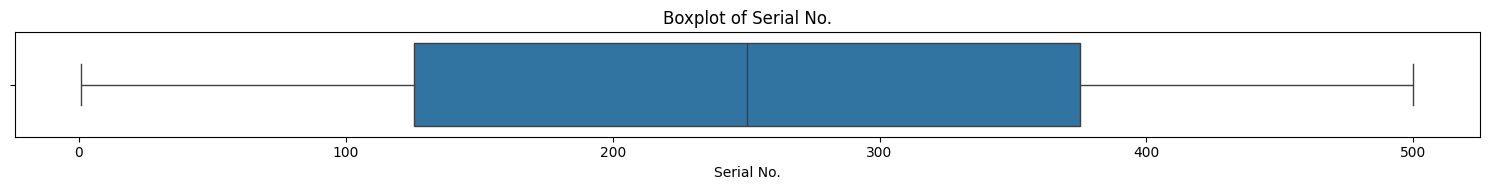

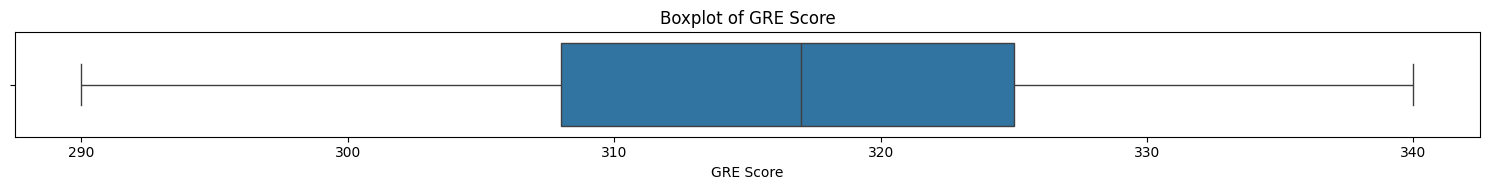

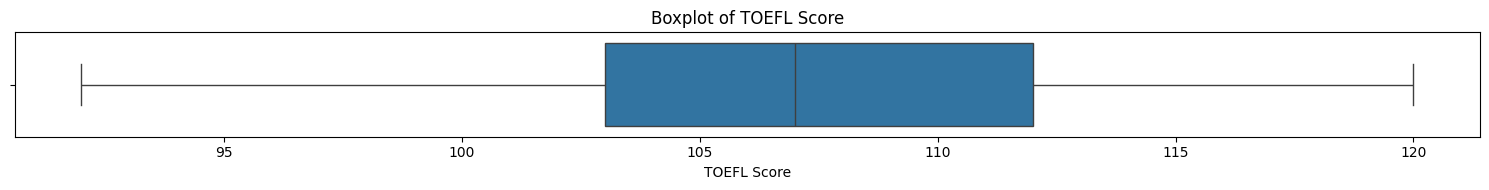

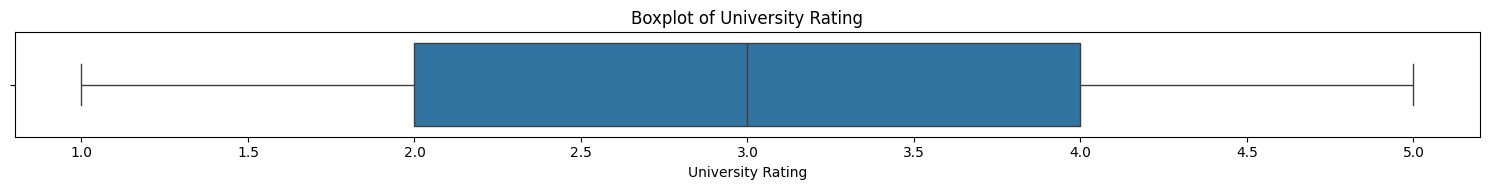

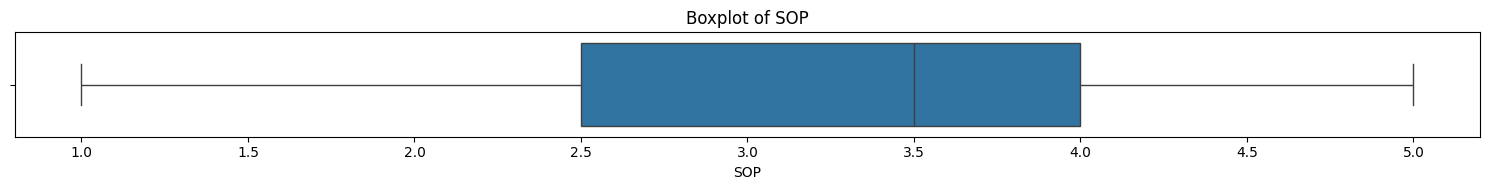

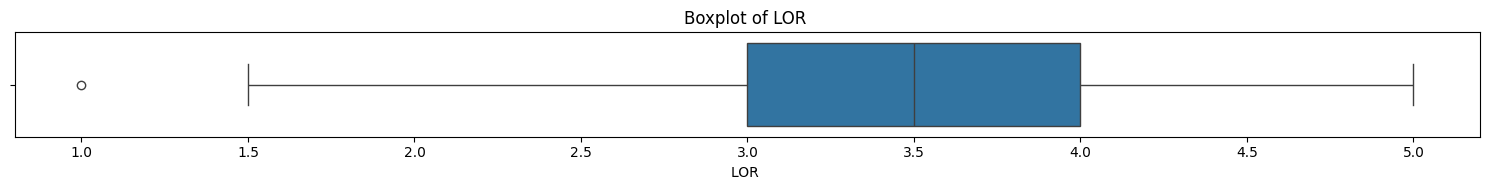

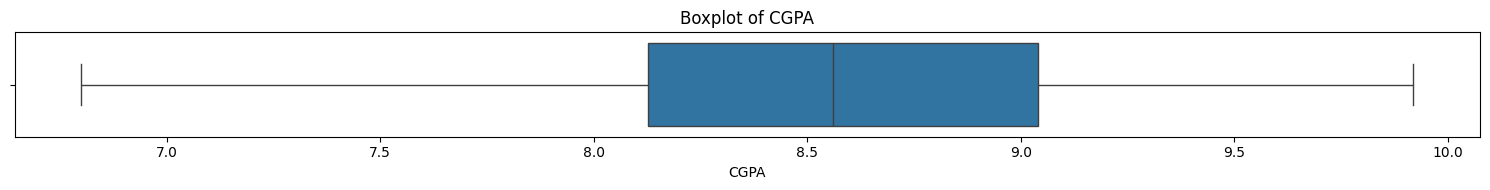

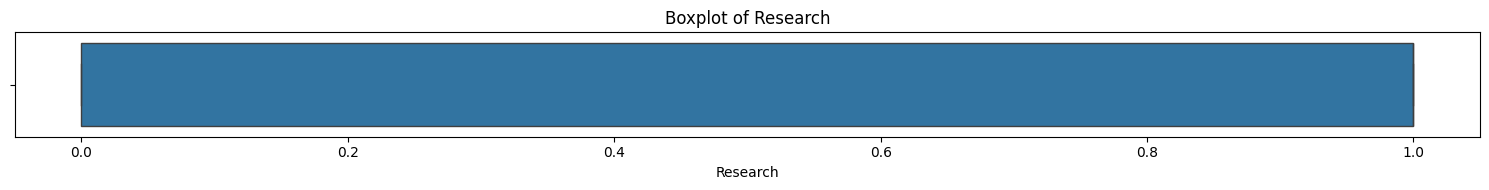

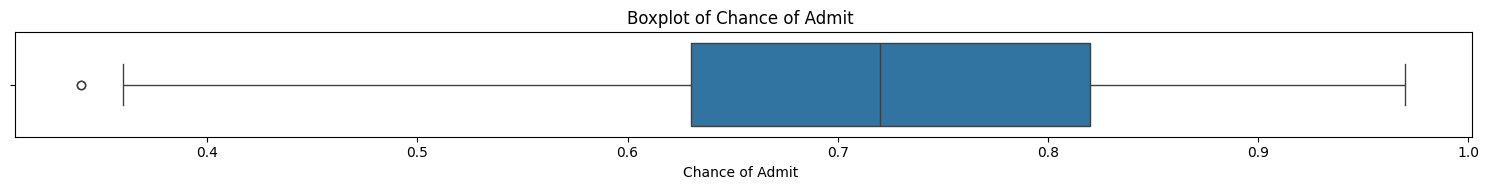

In [ ]:
for col in df.select_dtypes(include=['number']):
  plt.figure(figsize=(15,2))
  sns.boxplot(x =df[col])
  plt.title(f'Boxplot of {col}')
  plt.tight_layout()
  plt.show()

In [ ]:
highly_skewed = []
moderately_skewed = []
symmetric = []

for col, skw in sorted(df.skew().items()):
    if skw > 1 or skw < -1:
        highly_skewed.append((col, skw))
    elif 0.5 < abs(skw) <= 1:
        moderately_skewed.append((col, skw))
    else:
        symmetric.append((col, skw))

print("Highly Skewed:")
for col, skw in highly_skewed:
    print(f"{col}, Skewness: {skw}")

print("\nModerately Skewed:")
for col, skw in moderately_skewed:
    print(f"{col}, Skewness: {skw}")

print("\nSymmetric:")
for col, skw in symmetric:
    print(f"{col}, Skewness: {skw}")

Highly Skewed:

Moderately Skewed:

Symmetric:
CGPA, Skewness: -0.026612517318359303
Chance of Admit , Skewness: -0.289966210041158
GRE Score, Skewness: -0.03984185809159066
LOR , Skewness: -0.1452903146082398
Research, Skewness: -0.24247492100796933
SOP, Skewness: -0.22897239628779945
Serial No., Skewness: 0.0
TOEFL Score, Skewness: 0.09560097235726285
University Rating, Skewness: 0.09029498312712977


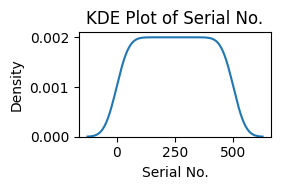

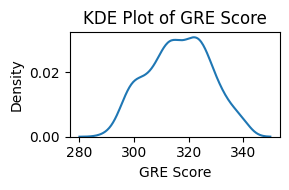

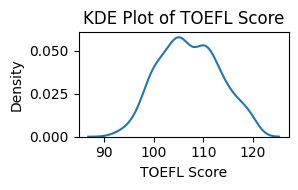

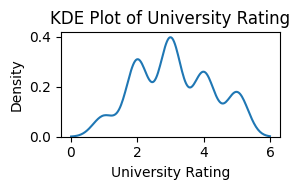

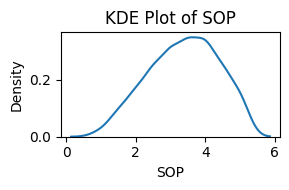

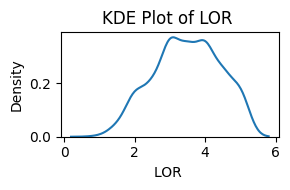

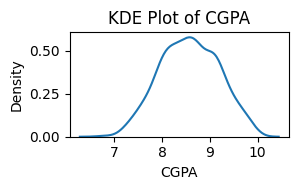

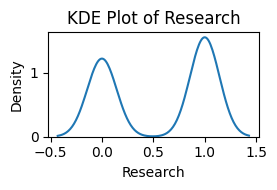

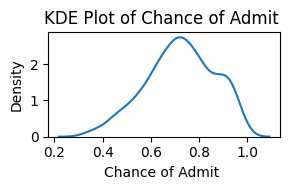

In [ ]:
for col in df.columns:
  plt.figure(figsize = (3,2))
  sns.kdeplot(df[col])
  plt.title(f'KDE Plot of {col}')
  plt.tight_layout()
  plt.show()

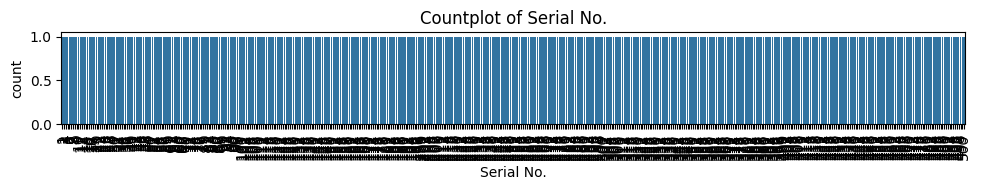

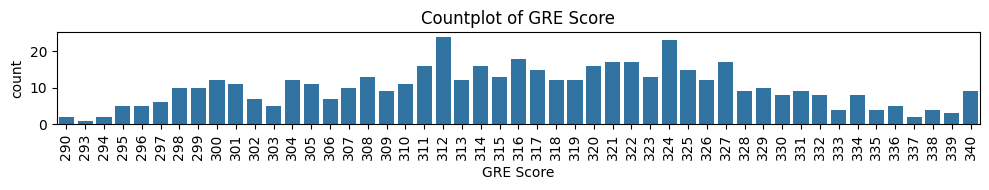

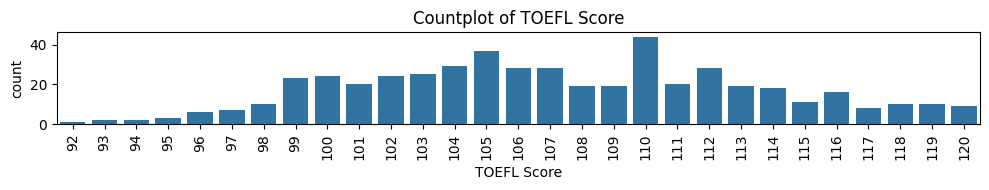

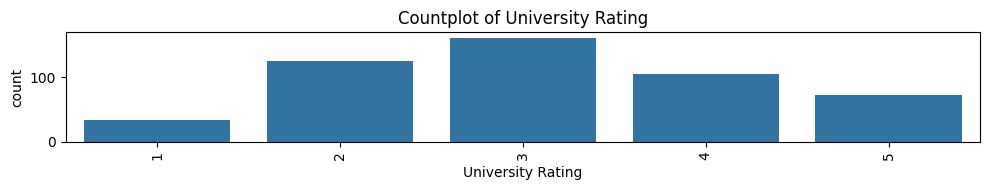

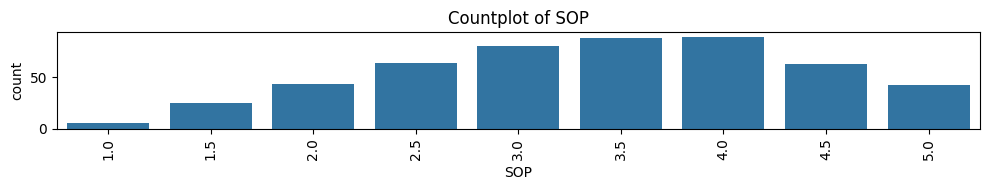

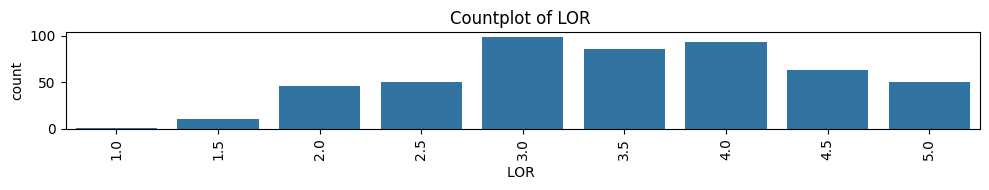

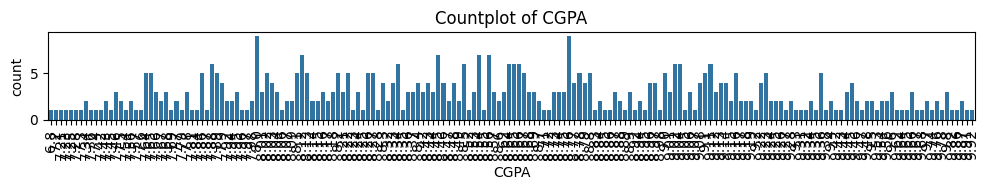

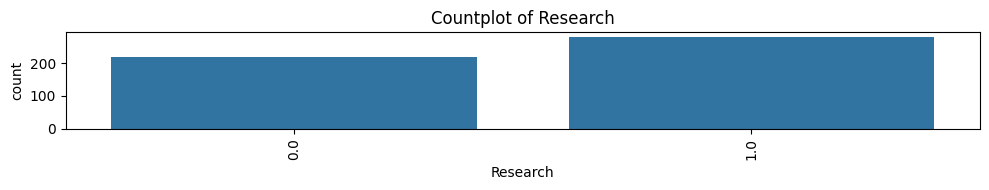

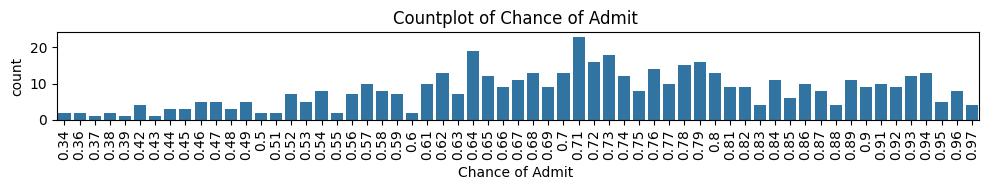

In [ ]:
for col in df.select_dtypes(include=['number']):
  plt.figure(figsize=(10,2))
  sns.countplot(x =df[col])
  plt.title(f'Countplot of {col}')
  plt.xticks(rotation=90)
  plt.tight_layout()
  plt.show()

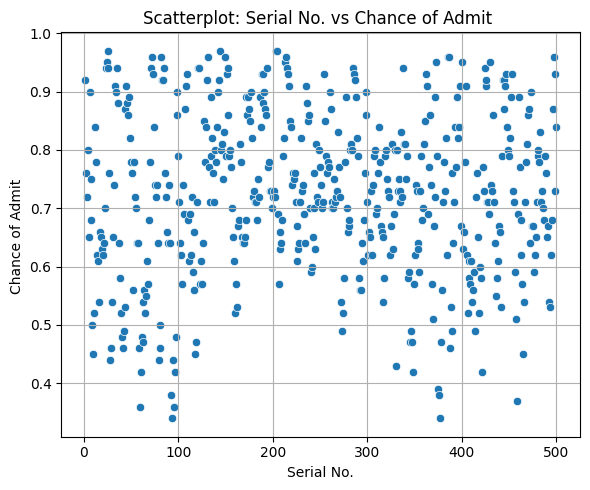

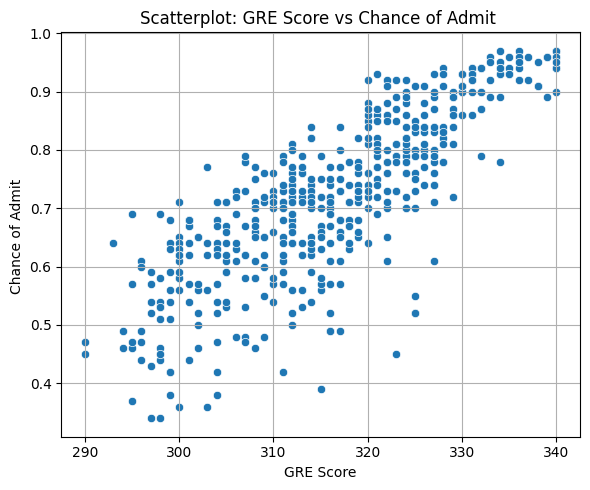

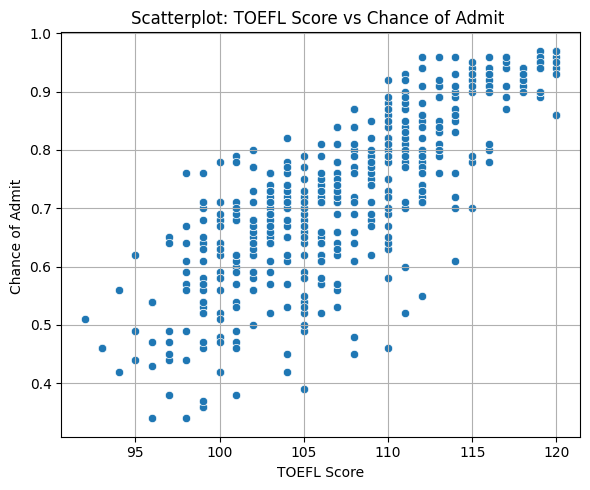

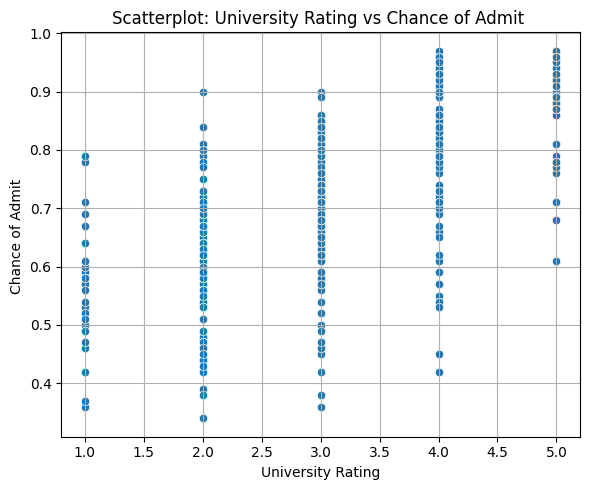

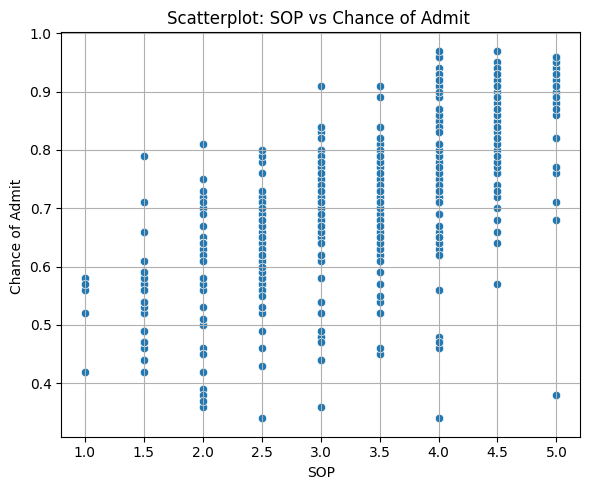

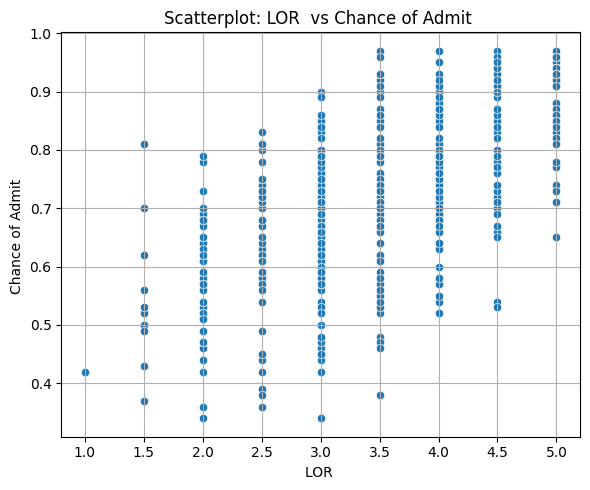

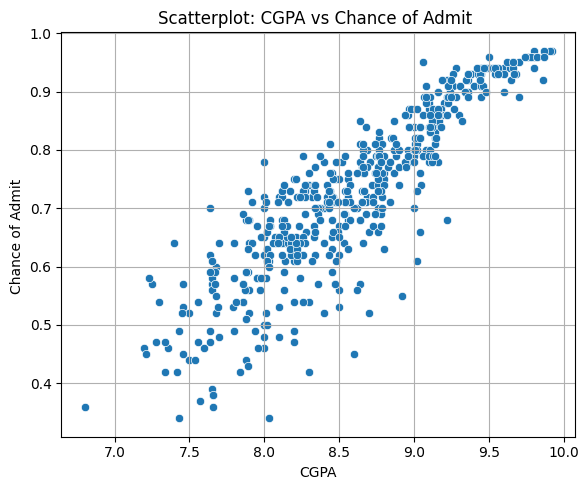

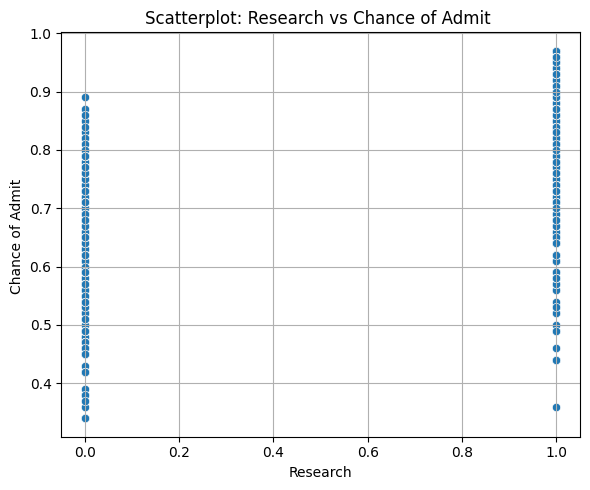

In [ ]:
target = 'Chance of Admit '
for col in df.select_dtypes(include='number'):
  if col != target:
    plt.figure(figsize=(6,5))
    sns.scatterplot(x=df[col], y=df[target])
    plt.title(f"Scatterplot: {col} vs {target}")
    plt.tight_layout()
    plt.grid(True)
    plt.show()

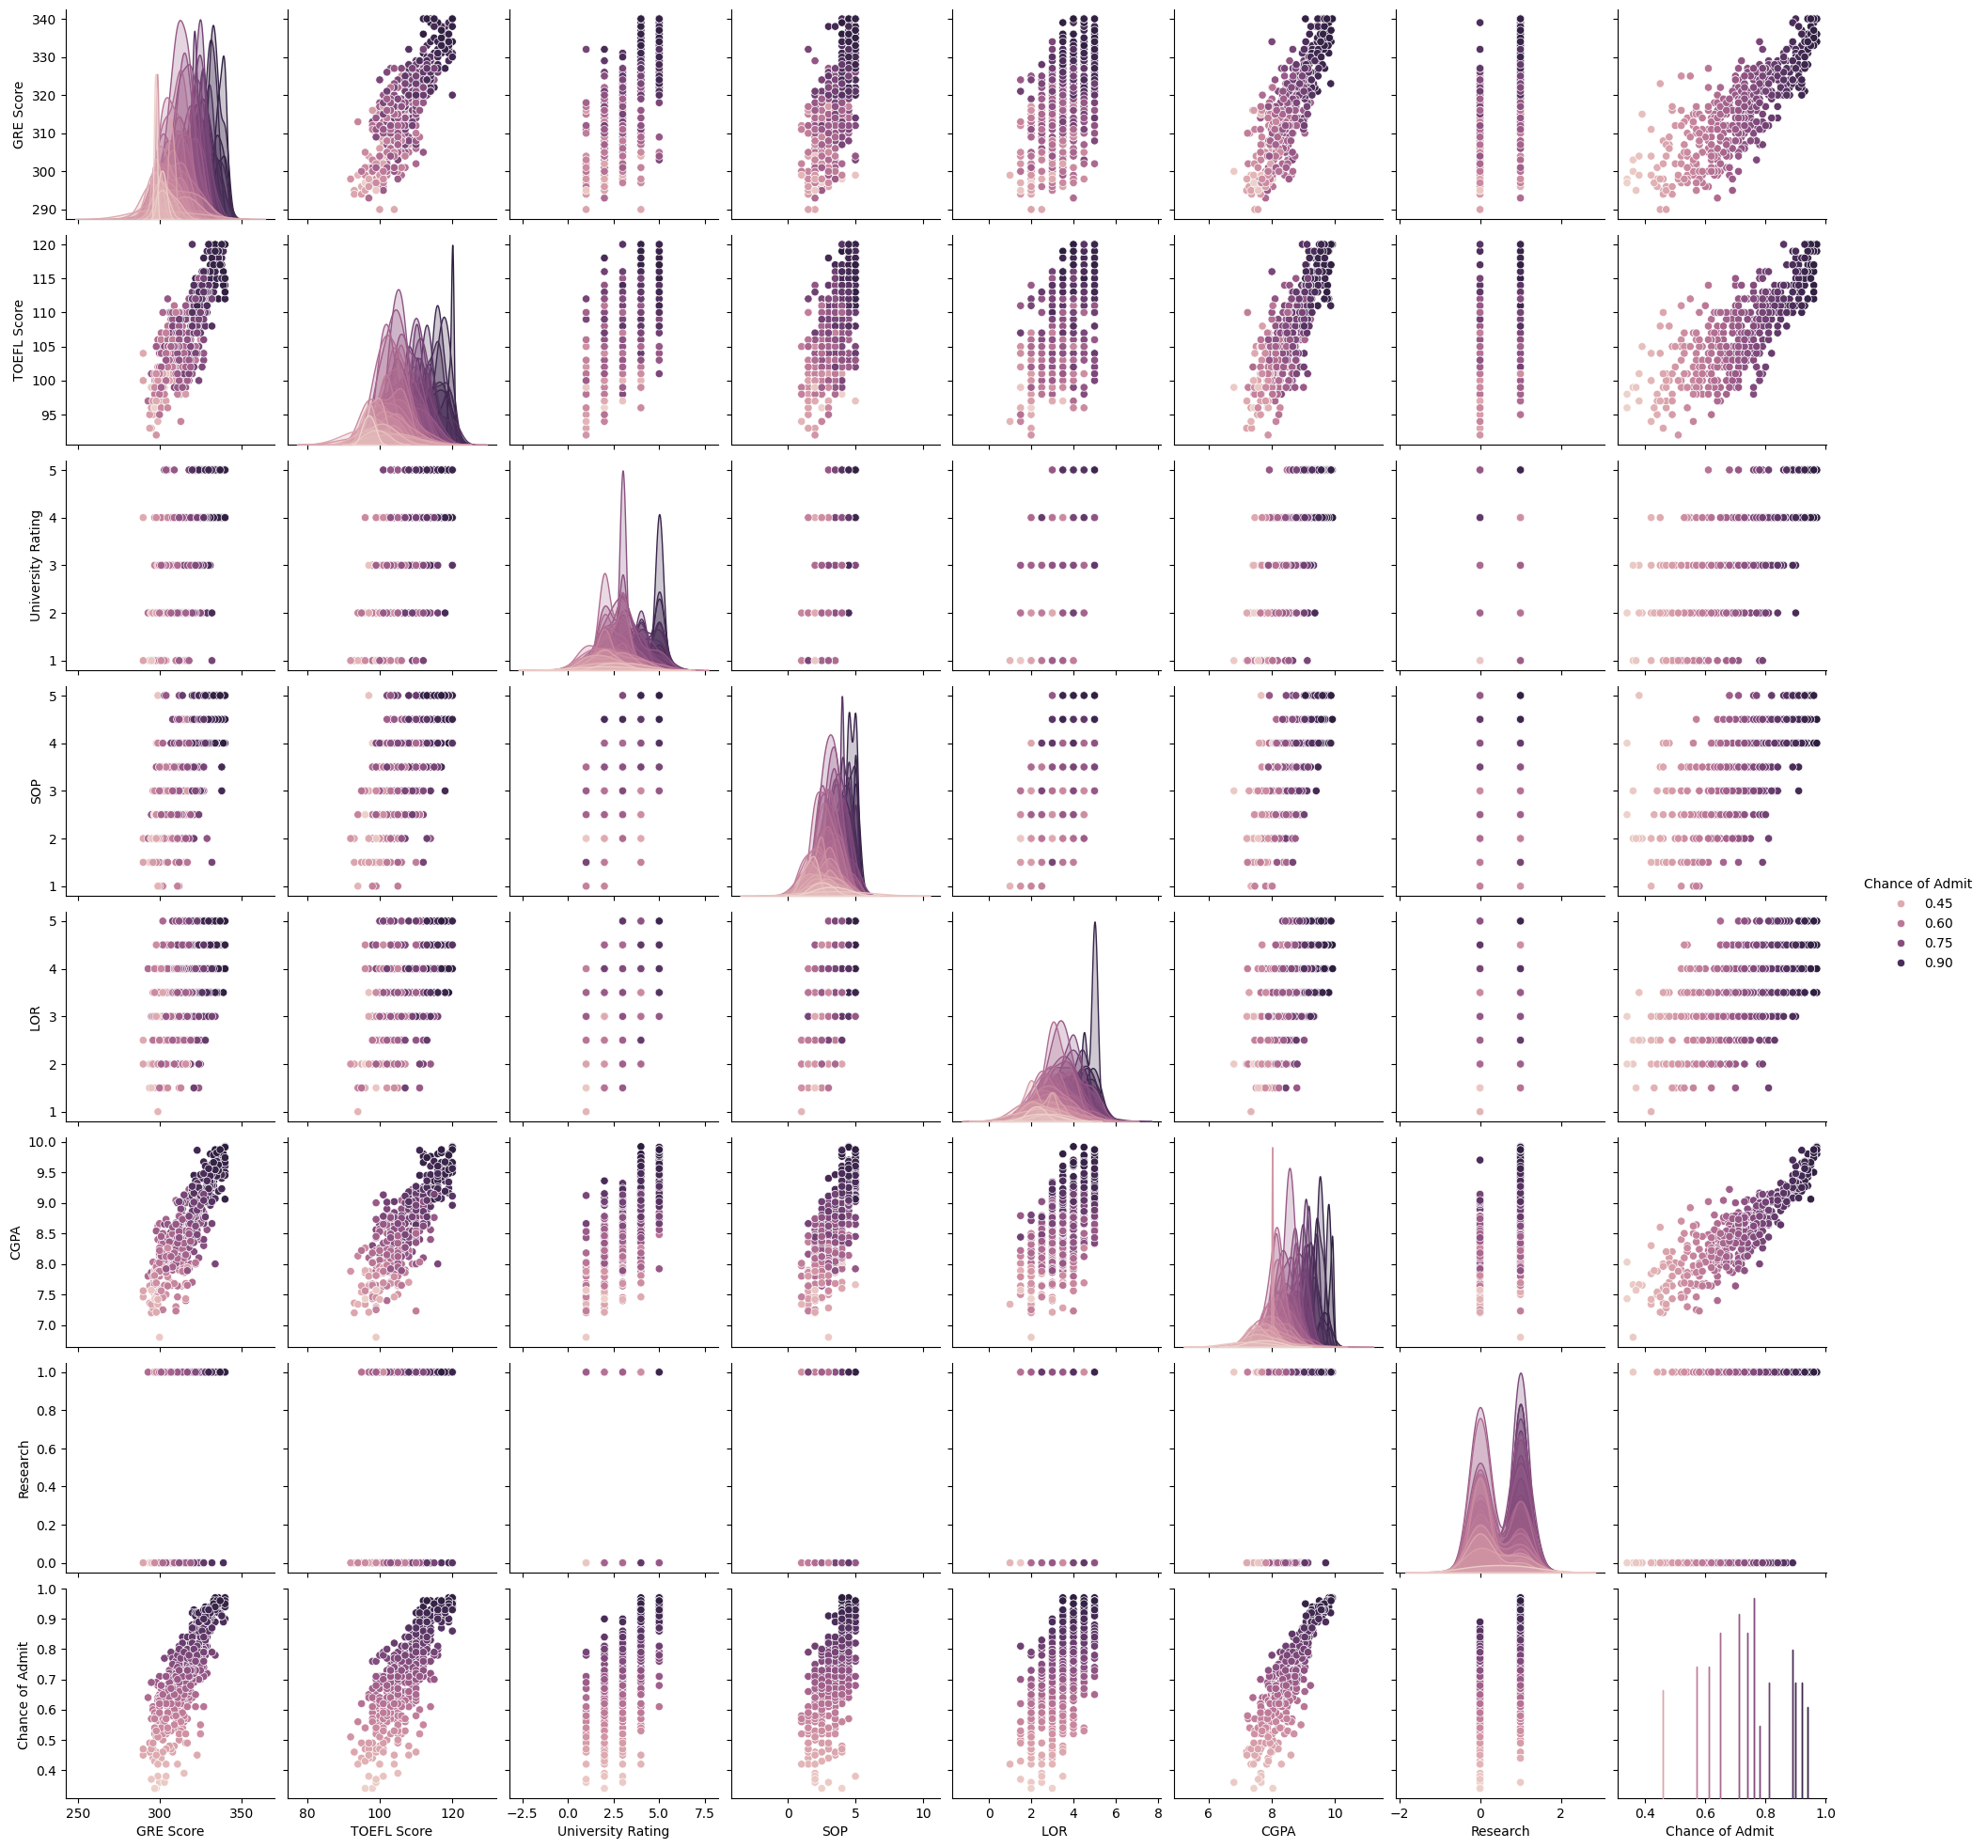

In [ ]:
features = ['GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit ']

sns.pairplot(df,hue='Chance of Admit ', vars= features , y_vars=['Chance of Admit '])
plt.grid(True)
plt.show()

In [ ]:
df.columns

Index(['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP',
       'LOR ', 'CGPA', 'Research', 'Chance of Admit '],
      dtype='object')

In [ ]:
X = df.drop(['Chance of Admit ','Serial No.'], axis=1)
y = df['Chance of Admit ']


X_train , X_test ,y_train , y_test = train_test_split(X,y,test_size=0.2 , random_state=42)


model = LinearRegression()


model.fit(X_train , y_train)


y_pred = model.predict(X_test)


mse = mean_squared_error(y_test , y_pred)
r2 = r2_score(y_test , y_pred)


print(f'Mean Squared Error: {mse}')
print(f'R-squared: {r2}')

Mean Squared Error: 0.003704655398788405
R-squared: 0.8188432567829631


In [ ]:
# Define the feature matrix (X) and the target variable (y)
X = df.drop(['Chance of Admit ', 'Serial No.'], axis=1)
y = df['Chance of Admit ']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a linear regression model
model = LinearRegression()

# Train the model using the training data
model.fit(X_train, y_train)

# Make predictions using the testing data
y_pred = model.predict(X_test)

# Evaluate the model's performance
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f'Mean Squared Error: {mse}')
print(f'R-Squared: {r2}')

Mean Squared Error: 0.003704655398788405
R-Squared: 0.8188432567829631


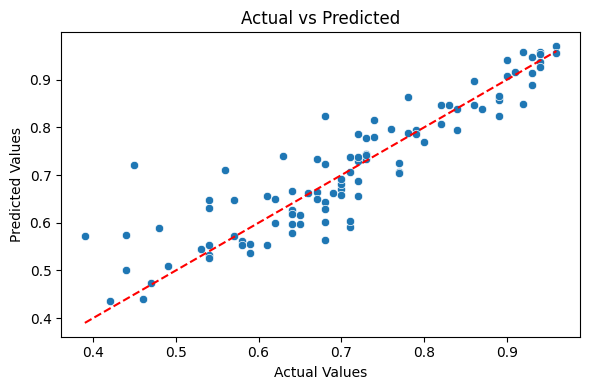

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=y_test, y=y_pred)

# perfect prediction line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--', color='red')

plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted')
plt.tight_layout()
plt.show()


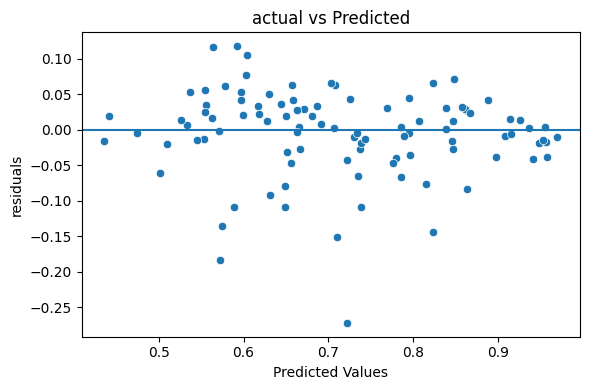

In [ ]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))
sns.scatterplot(x=y_pred,y=residuals)
plt.axhline(0)
plt.xlabel('Predicted Values')
plt.ylabel('residuals')
plt.title('actual vs Predicted')
plt.tight_layout()
plt.show()



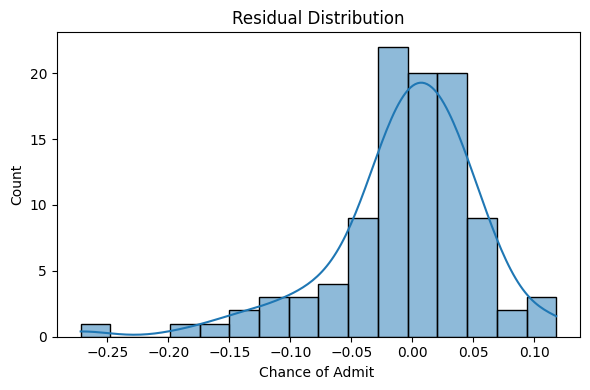

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(residuals,kde=True)
plt.title('Residual Distribution')
plt.tight_layout()
plt.show()

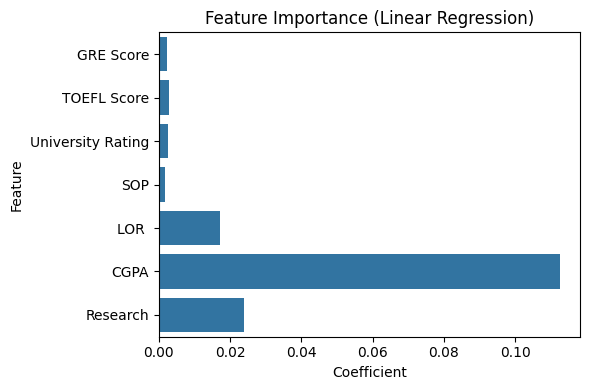

In [ ]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

plt.figure(figsize=(6,4))
sns.barplot(x='Coefficient',y='Feature',data=coeff_df)
plt.title('Feature Importance (Linear Regression)')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd

# Features and target
X = df.drop(['Chance of Admit ', 'Serial No.'], axis=1)
y = df['Chance of Admit ']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Standard scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train Linear Regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

# Evaluation
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("=" * 50)
print(f"MSE: {mse:.5f}")
print("=" * 50)
print("R-squared:", r2)
print("=" * 50)

MSE: 0.00370
R-squared: 0.8188432567829627


In [ ]:
plt.figure(figsize=(6,4))
sns.barplot(x='Coefficient')